Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 1463.7063 - mae: 35.8053 - val_loss: 862.8998 - val_mae: 25.5206
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 1109.5776 - mae: 30.1515 - val_loss: 598.0966 - val_mae: 20.5939
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 836.9963 - mae: 25.2529 - val_loss: 432.5792 - val_mae: 17.0342
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 644.2600 - mae: 20.9486 - val_loss: 362.7948 - val_mae: 14.5461
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 528.5582 - mae: 18.2326 - val_loss: 371.5531 - val_mae: 15.7363
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 479.6720 - mae: 16.7866 - val_loss: 432.7825 - val_mae: 17.5569
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 480.6282 - mae: 16.5468 - val_loss: 514.2919 - val_mae: 19.1123
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 506.8934 - mae: 17.2346 - val_loss: 581.4916 - val_mae: 20.3678
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━

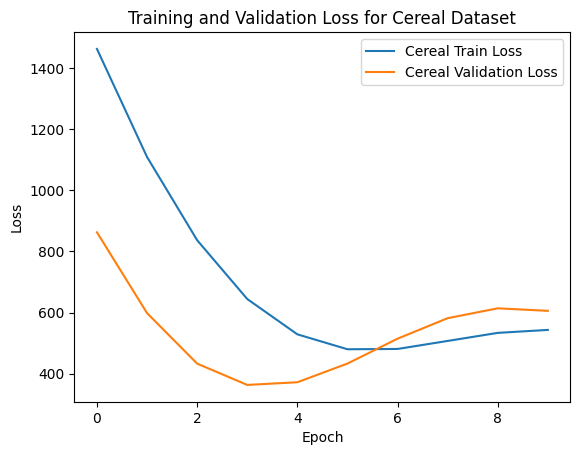

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras import Input
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import pandas as pd

# Load datasets from Kaggle
# Make sure you have your Kaggle API key set up properly to use the Kaggle datasets
# Here, we assume you've already downloaded the datasets and placed them in your working directory
# cereal_data = pd.read_csv("cereal.csv")
# concrete_data = pd.read_csv("concrete.csv")
cereal_data = pd.read_csv("https://github.com/ML-Course-2026/session5/raw/refs/heads/main/material/datasets/cereal.csv")
concrete_data = pd.read_csv("https://github.com/ML-Course-2026/session5/raw/refs/heads/main/material/datasets/concrete.csv")
# Preprocess datasets
# For simplicity, we'll use only a subset of features for each dataset and treat it as a regression problem

# Cereal dataset preprocessing
cereal_features = cereal_data[['calories', 'protein', 'fat', 'sodium', 'fiber', 'carbo', 'sugars', 'potass', 'vitamins']]
cereal_target = cereal_data['rating']

# Concrete dataset preprocessing
concrete_features = concrete_data.drop(columns=['CompressiveStrength'])
concrete_target = concrete_data['CompressiveStrength']

# Split datasets into training and testing sets
cereal_X_train, cereal_X_test, cereal_y_train, cereal_y_test = train_test_split(cereal_features, cereal_target, test_size=0.2, random_state=42)
concrete_X_train, concrete_X_test, concrete_y_train, concrete_y_test = train_test_split(concrete_features, concrete_target, test_size=0.2, random_state=42)

# Define a Sequential model
model = Sequential()
model.add(Input(shape=(cereal_X_train.shape[1],)))
# Add dense layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))# Output layer for regression task

# Compile the model
model.compile(optimizer='adam',
              loss='mean_squared_error',  # Use MSE loss for regression
              metrics=['mae'])

# Print model summary
model.summary()

# Train the model on cereal dataset
history_cereal = model.fit(cereal_X_train, cereal_y_train, epochs=10, batch_size=64, validation_data=(cereal_X_test, cereal_y_test), verbose=1)

# Plot training history for cereal dataset
plt.plot(history_cereal.history['loss'], label='Cereal Train Loss')
plt.plot(history_cereal.history['val_loss'], label='Cereal Validation Loss')

plt.title('Training and Validation Loss for Cereal Dataset')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()